In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("default")

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUMMARY_PATH = PROJECT_ROOT / "results" / "architecture_results" / "summary.csv"
summary = pd.read_csv(SUMMARY_PATH)

metric_cols = [
    "loss",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
]
higher_is_better = {metric: metric != "loss" for metric in metric_cols}
summary["dataset_size"] = summary["total_size"].astype(int)
summary = summary.sort_values(["dataset_name", "method"]).reset_index(drop=True)

print(f"Loaded {len(summary)} rows from {SUMMARY_PATH}")
display(summary.head())



Loaded 36 rows from /Users/roman/Desktop/НИР/FUTURE/results/architecture_results/summary.csv


,method,dataset_name,train_size,test_size,total_size,channels,time_steps,num_classes,loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,dataset_size
0,GAF,ECG5000,500,4500,5000,1,140,5,0.3742,0.9378,0.5683,0.6367,0.5683,0.5955,0.9296,0.9378,0.9328,5000
1,MTF,ECG5000,500,4500,5000,1,140,5,0.4112,0.9349,0.4706,0.6241,0.4706,0.4981,0.9222,0.9349,0.9193,5000
2,STFT,ECG5000,500,4500,5000,1,140,5,0.4181,0.9282,0.5499,0.6035,0.5499,0.5618,0.9218,0.9282,0.9245,5000
3,raw,ECG5000,500,4500,5000,1,140,5,0.3327,0.9382,0.5341,0.8133,0.5341,0.5729,0.9294,0.9382,0.9295,5000
4,raw_GAF,ECG5000,500,4500,5000,1,140,5,0.3115,0.9371,0.5843,0.6363,0.5843,0.6060,0.9314,0.9371,0.9337,5000


In [3]:
def best_rows_by_metric(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for dataset_name, dataset_df in df.groupby("dataset_name", sort=True):
        dataset_size = int(dataset_df["total_size"].iloc[0])
        for metric in metrics:
            idx = dataset_df[metric].idxmax() if higher_is_better[metric] else dataset_df[metric].idxmin()
            best = dataset_df.loc[idx]
            rows.append(
                {
                    "dataset_name": dataset_name,
                    "dataset_size": dataset_size,
                    "metric": metric,
                    "best_method": best["method"],
                    "best_value": best[metric],
                }
            )
    return pd.DataFrame(rows)

best_by_metric = best_rows_by_metric(summary, metric_cols)

best_by_metric_style = (
    best_by_metric
    .style
    .format({"best_value": "{:.4f}"})
    .set_caption("Best method for each dataset and metric")
)
display(best_by_metric_style)


,dataset_name,dataset_size,metric,best_method,best_value
0,ECG5000,5000,loss,stats,0.2733
1,ECG5000,5000,accuracy,stats,0.9420
2,ECG5000,5000,balanced_accuracy,raw_GAF,0.5843
3,ECG5000,5000,macro_precision,raw,0.8133
4,ECG5000,5000,macro_recall,raw_GAF,0.5843
5,ECG5000,5000,macro_f1,raw_GAF,0.6060
6,ECG5000,5000,weighted_precision,stats,0.9331
7,ECG5000,5000,weighted_recall,stats,0.9420
8,ECG5000,5000,weighted_f1,raw_GAF,0.9337
9,FacesUCR,2250,loss,raw,0.4476


Best combinations by macro_f1:


,dataset_name,dataset_size,method,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
4,ECG5000,5000,raw_GAF,0.3115,0.9371,0.5843,0.6060,0.9337
11,FacesUCR,2250,STFT,0.4890,0.9020,0.8507,0.8640,0.8986
21,MedicalImages,1141,raw,0.6426,0.7789,0.7613,0.7604,0.7792
30,SwedishLeaf,1125,raw,0.1684,0.9424,0.9433,0.9424,0.9415


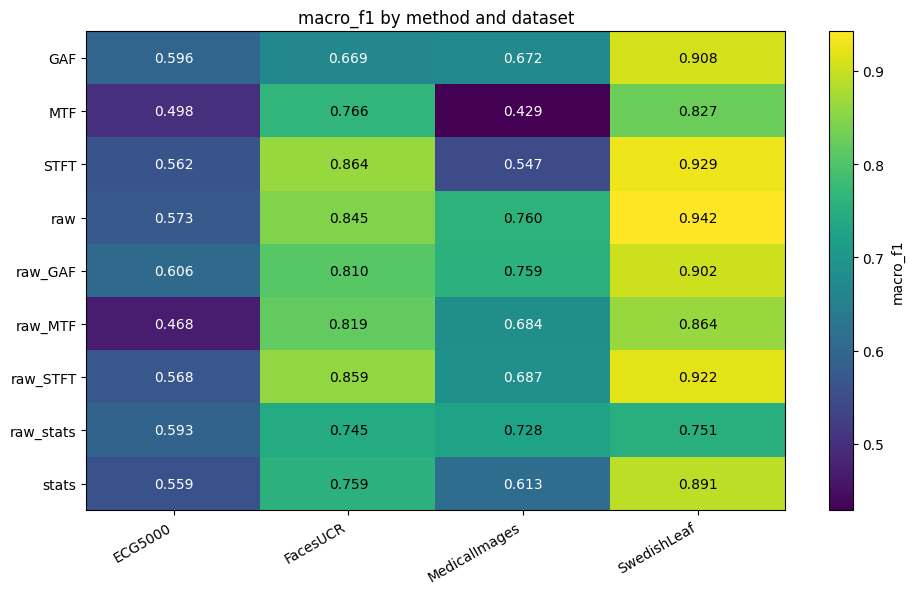

In [4]:
primary_metric = "macro_f1"

primary_pivot = summary.pivot(index="method", columns="dataset_name", values=primary_metric)
primary_best = summary.loc[summary.groupby("dataset_name")[primary_metric].idxmax()].sort_values("dataset_name")

print(f"Best combinations by {primary_metric}:")
display(
    primary_best[
        [
            "dataset_name",
            "dataset_size",
            "method",
            "loss",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ].style.format(
        {
            "loss": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "weighted_f1": "{:.4f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(1.2 * primary_pivot.shape[1] + 5, 0.45 * primary_pivot.shape[0] + 2))
im = ax.imshow(primary_pivot, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(primary_pivot.shape[1]), labels=primary_pivot.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(primary_pivot.shape[0]), labels=primary_pivot.index)
ax.set_title(f"{primary_metric} by method and dataset")

for i in range(primary_pivot.shape[0]):
    for j in range(primary_pivot.shape[1]):
        value = primary_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value < primary_pivot.max().max() * 0.75 else "black")

fig.colorbar(im, ax=ax, label=primary_metric)
plt.tight_layout()
plt.show()


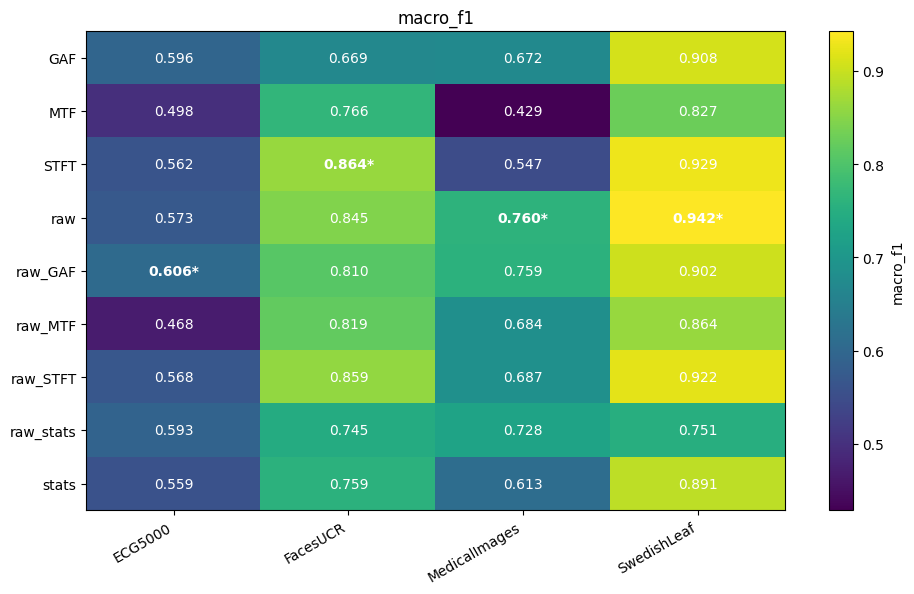

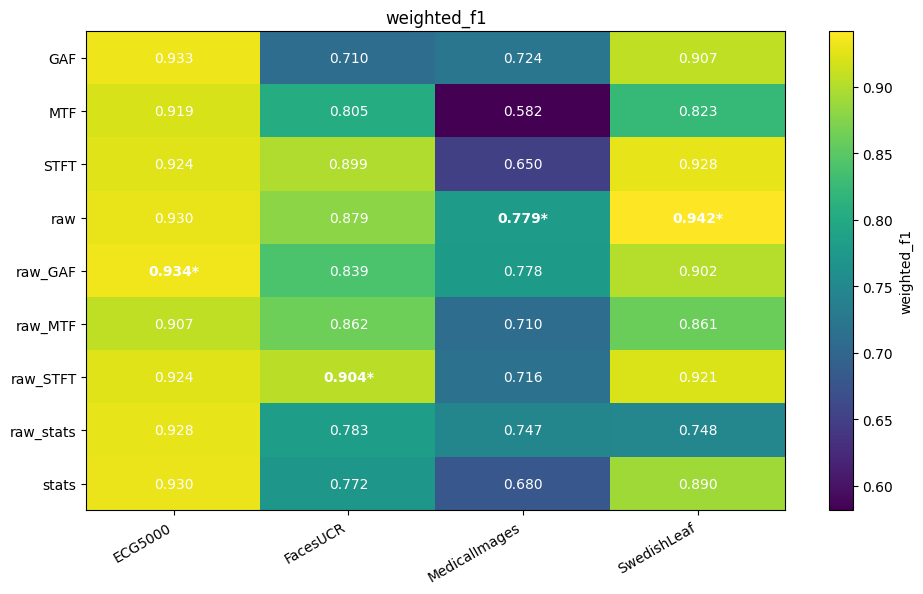

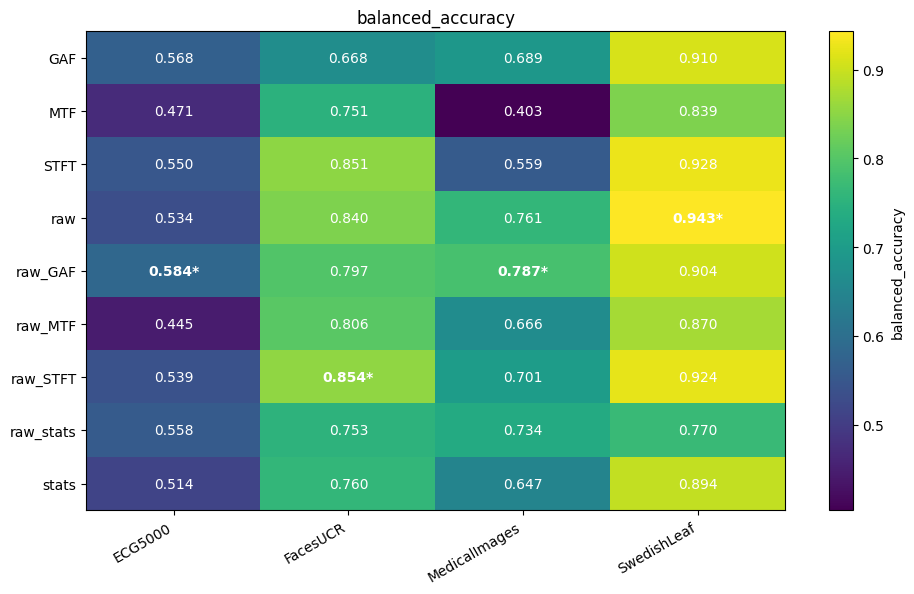

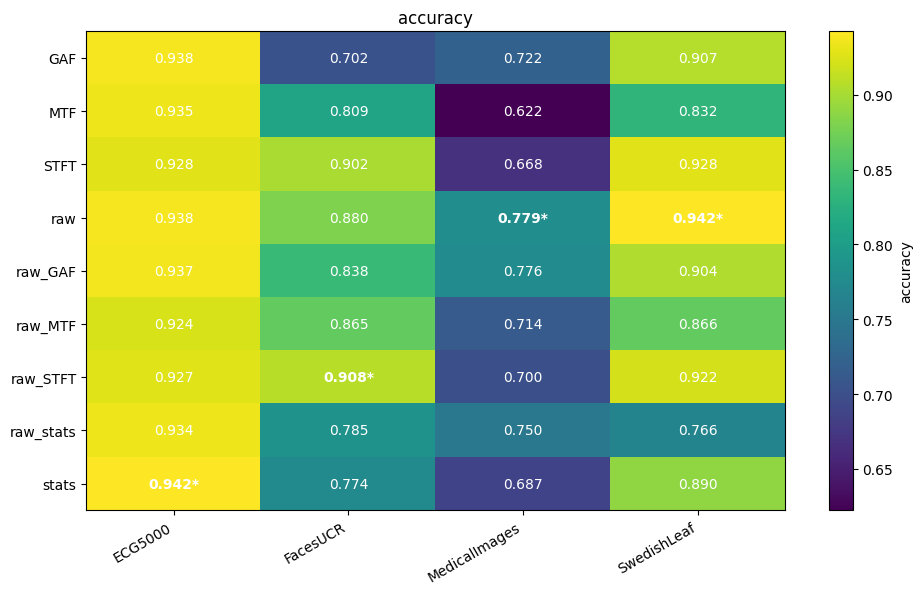

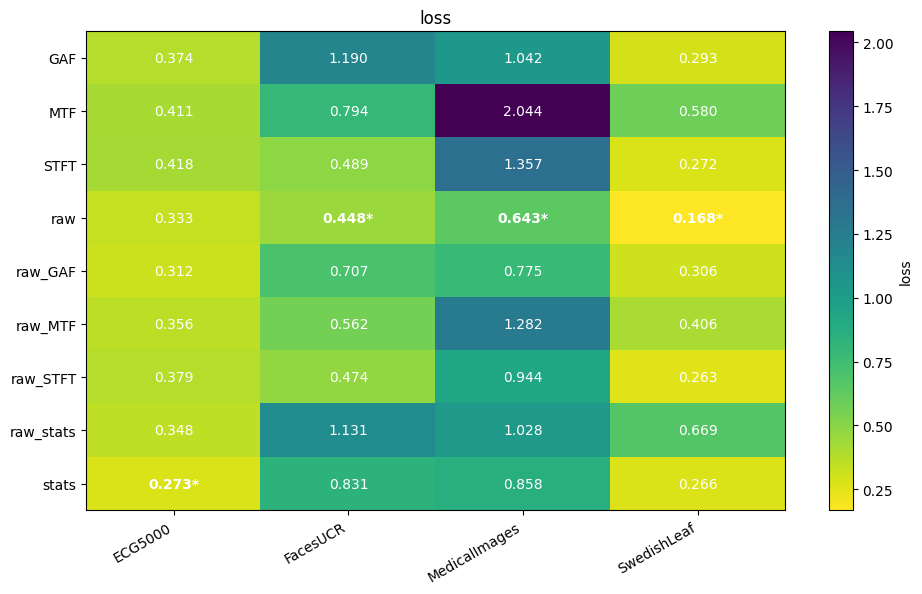

In [5]:
def plot_metric_heatmap(metric: str, *, cmap: str | None = None) -> None:
    pivot = summary.pivot(index="method", columns="dataset_name", values=metric)
    best_idx = pivot.idxmin(axis=0) if not higher_is_better[metric] else pivot.idxmax(axis=0)
    cmap = cmap or ("viridis" if higher_is_better[metric] else "viridis_r")

    fig, ax = plt.subplots(figsize=(1.2 * pivot.shape[1] + 5, 0.45 * pivot.shape[0] + 2))
    im = ax.imshow(pivot, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(pivot.shape[1]), labels=pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(pivot.shape[0]), labels=pivot.index)
    ax.set_title(metric)

    for i, method in enumerate(pivot.index):
        for j, dataset_name in enumerate(pivot.columns):
            value = pivot.loc[method, dataset_name]
            is_best = method == best_idx[dataset_name]
            label = f"{value:.3f}" + ("*" if is_best else "")
            ax.text(j, i, label, ha="center", va="center", color="white", fontweight="bold" if is_best else "normal")

    fig.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

for metric in ["macro_f1", "weighted_f1", "balanced_accuracy", "accuracy", "loss"]:
    plot_metric_heatmap(metric)


In [6]:
def add_metric_ranks(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    ranked = df.copy()
    rank_cols = []
    for metric in metrics:
        rank_col = f"rank_{metric}"
        ranked[rank_col] = ranked.groupby("dataset_name")[metric].rank(
            ascending=not higher_is_better[metric],
            method="min",
        )
        rank_cols.append(rank_col)
    ranked["mean_rank"] = ranked[rank_cols].mean(axis=1)
    ranked["is_best_macro_f1"] = ranked["rank_macro_f1"].eq(1)
    return ranked

ranked_summary = add_metric_ranks(summary, metric_cols)
method_rating = (
    ranked_summary
    .groupby("method", as_index=False)
    .agg(
        mean_rank=("mean_rank", "mean"),
        median_rank=("mean_rank", "median"),
        wins_macro_f1=("is_best_macro_f1", "sum"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_weighted_f1=("weighted_f1", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_loss=("loss", "mean"),
    )
    .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Overall method rating: lower mean_rank is better")
display(
    method_rating.style.format(
        {
            "mean_rank": "{:.2f}",
            "median_rank": "{:.2f}",
            "mean_macro_f1": "{:.4f}",
            "mean_weighted_f1": "{:.4f}",
            "mean_balanced_accuracy": "{:.4f}",
            "mean_accuracy": "{:.4f}",
            "mean_loss": "{:.4f}",
        }
    ).background_gradient(subset=["mean_rank"], cmap="viridis_r")
)


Overall method rating: lower mean_rank is better


,method,mean_rank,median_rank,wins_macro_f1,mean_macro_f1,mean_weighted_f1,mean_balanced_accuracy,mean_accuracy,mean_loss
0,raw,2.17,2.06,2,0.7802,0.8824,0.7697,0.8850,0.3978
1,raw_GAF,3.58,3.72,1,0.7693,0.8632,0.7682,0.8639,0.5249
2,raw_STFT,3.78,3.78,0,0.7592,0.8662,0.7544,0.8641,0.5149
3,STFT,4.69,4.44,1,0.7255,0.8503,0.7220,0.8566,0.6338
4,GAF,5.39,4.67,0,0.7114,0.8184,0.7088,0.8174,0.7247
5,stats,5.75,6.11,0,0.7054,0.8182,0.7037,0.8230,0.5572
6,raw_stats,5.92,5.78,0,0.7041,0.8016,0.7036,0.8090,0.7944
7,raw_MTF,6.06,6.28,0,0.7087,0.8349,0.6969,0.8422,0.6513
8,MTF,7.67,7.61,0,0.6300,0.7823,0.6160,0.7995,0.9571


In [7]:
comparison_metric = "macro_f1"
baseline_method = "raw"

baseline = summary.loc[summary["method"] == baseline_method, ["dataset_name", comparison_metric]].rename(
    columns={comparison_metric: f"{baseline_method}_{comparison_metric}"}
)
comparison = summary.merge(baseline, on="dataset_name", how="left")
comparison[f"delta_vs_{baseline_method}"] = comparison[comparison_metric] - comparison[f"{baseline_method}_{comparison_metric}"]
comparison = comparison.sort_values(["dataset_name", f"delta_vs_{baseline_method}"], ascending=[True, False])

print(f"Delta in {comparison_metric} versus {baseline_method} baseline")
display(
    comparison[
        [
            "dataset_name",
            "dataset_size",
            "method",
            comparison_metric,
            f"{baseline_method}_{comparison_metric}",
            f"delta_vs_{baseline_method}",
        ]
    ].style.format(
        {
            comparison_metric: "{:.4f}",
            f"{baseline_method}_{comparison_metric}": "{:.4f}",
            f"delta_vs_{baseline_method}": "{:+.4f}",
        }
    ).background_gradient(subset=[f"delta_vs_{baseline_method}"], cmap="RdYlGn")
)


Delta in macro_f1 versus raw baseline


,dataset_name,dataset_size,method,macro_f1,raw_macro_f1,delta_vs_raw
4,ECG5000,5000,raw_GAF,0.6060,0.5729,+0.0331
0,ECG5000,5000,GAF,0.5955,0.5729,+0.0227
7,ECG5000,5000,raw_stats,0.5927,0.5729,+0.0198
3,ECG5000,5000,raw,0.5729,0.5729,+0.0000
6,ECG5000,5000,raw_STFT,0.5684,0.5729,-0.0044
2,ECG5000,5000,STFT,0.5618,0.5729,-0.0110
8,ECG5000,5000,stats,0.5591,0.5729,-0.0138
1,ECG5000,5000,MTF,0.4981,0.5729,-0.0748
5,ECG5000,5000,raw_MTF,0.4678,0.5729,-0.1050
11,FacesUCR,2250,STFT,0.8640,0.8451,+0.0189


## Representation Concat Experiments

Results for the additional concat models:

- `raw_stats_STFT`
- `raw_stats_GAF`
- `raw_stats_GAF_STFT`
- `raw_stats_GAF_MTF_STFT`

This block also isolates the effect of adding `MTF` to `raw_stats_GAF_STFT`.

In [8]:
REPRESENTATION_RESULTS_DIR = PROJECT_ROOT / "results" / "representation_concat_results"
REPRESENTATION_SUMMARY_PATH = REPRESENTATION_RESULTS_DIR / "summary.csv"
MTF_COMPARISON_PATH = REPRESENTATION_RESULTS_DIR / "mtf_comparison.csv"

if REPRESENTATION_SUMMARY_PATH.exists():
    representation_summary = pd.read_csv(REPRESENTATION_SUMMARY_PATH)
    representation_summary["dataset_size"] = representation_summary["total_size"].astype(int)
    representation_summary = representation_summary.sort_values(["dataset_name", "method"]).reset_index(drop=True)
    print(f"Loaded {len(representation_summary)} rows from {REPRESENTATION_SUMMARY_PATH}")
    display(representation_summary)
else:
    representation_summary = pd.DataFrame()
    print(f"No representation concat summary found: {REPRESENTATION_SUMMARY_PATH}")


Loaded 16 rows from /Users/roman/Desktop/НИР/FUTURE/results/representation_concat_results/summary.csv


,method,dataset_name,train_size,test_size,total_size,channels,time_steps,num_classes,loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,dataset_size
0,raw_stats_GAF,ECG5000,500,4500,5000,1,140,5,0.2951,0.9369,0.5315,0.6714,0.5315,0.5661,0.9264,0.9369,0.9294,5000
1,raw_stats_GAF_MTF_STFT,ECG5000,500,4500,5000,1,140,5,0.3726,0.9404,0.5236,0.6444,0.5236,0.5597,0.9285,0.9404,0.9309,5000
2,raw_stats_GAF_STFT,ECG5000,500,4500,5000,1,140,5,0.3050,0.9420,0.5476,0.6417,0.5476,0.5761,0.9321,0.9420,0.9333,5000
3,raw_stats_STFT,ECG5000,500,4500,5000,1,140,5,0.2693,0.9371,0.4899,0.5872,0.4899,0.5086,0.9179,0.9371,0.9231,5000
4,raw_stats_GAF,FacesUCR,200,2050,2250,1,131,14,0.9774,0.8239,0.8006,0.8262,0.8006,0.8076,0.8352,0.8239,0.8237,2250
5,raw_stats_GAF_MTF_STFT,FacesUCR,200,2050,2250,1,131,14,0.7200,0.8610,0.8443,0.8405,0.8443,0.8399,0.8657,0.8610,0.8608,2250
6,raw_stats_GAF_STFT,FacesUCR,200,2050,2250,1,131,14,0.7732,0.8478,0.8334,0.8430,0.8334,0.8321,0.8599,0.8478,0.8473,2250
7,raw_stats_STFT,FacesUCR,200,2050,2250,1,131,14,0.8645,0.8415,0.8088,0.8497,0.8088,0.8223,0.8526,0.8415,0.8411,2250
8,raw_stats_GAF,MedicalImages,381,760,1141,1,99,10,1.0752,0.7618,0.7373,0.7150,0.7373,0.7083,0.7586,0.7618,0.7514,1141
9,raw_stats_GAF_MTF_STFT,MedicalImages,381,760,1141,1,99,10,1.1167,0.7632,0.7423,0.7766,0.7423,0.7498,0.7756,0.7632,0.7629,1141


Best new concat model by macro_f1:


,dataset_name,dataset_size,method,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,ECG5000,5000,raw_stats_GAF_STFT,0.3050,0.9420,0.5476,0.5761,0.9333
5,FacesUCR,2250,raw_stats_GAF_MTF_STFT,0.7200,0.8610,0.8443,0.8399,0.8608
9,MedicalImages,1141,raw_stats_GAF_MTF_STFT,1.1167,0.7632,0.7423,0.7498,0.7629
15,SwedishLeaf,1125,raw_stats_STFT,0.2712,0.9216,0.9244,0.9218,0.9205


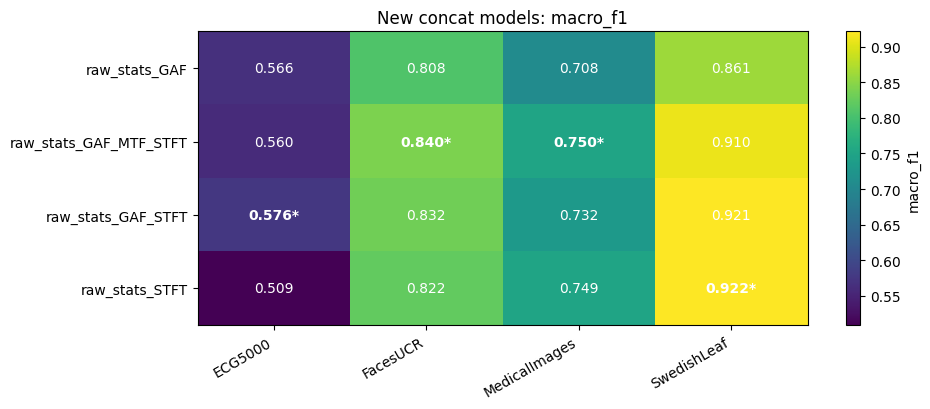

In [9]:
if not representation_summary.empty:
    rep_primary_metric = "macro_f1"
    rep_best = (
        representation_summary
        .loc[representation_summary.groupby("dataset_name")[rep_primary_metric].idxmax()]
        .sort_values("dataset_name")
    )

    print(f"Best new concat model by {rep_primary_metric}:")
    display(
        rep_best[
            [
                "dataset_name",
                "dataset_size",
                "method",
                "loss",
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ].style.format(
            {
                "loss": "{:.4f}",
                "accuracy": "{:.4f}",
                "balanced_accuracy": "{:.4f}",
                "macro_f1": "{:.4f}",
                "weighted_f1": "{:.4f}",
            }
        )
    )

    rep_pivot = representation_summary.pivot(index="method", columns="dataset_name", values=rep_primary_metric)
    fig, ax = plt.subplots(figsize=(1.2 * rep_pivot.shape[1] + 5, 0.55 * rep_pivot.shape[0] + 2))
    im = ax.imshow(rep_pivot, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(rep_pivot.shape[1]), labels=rep_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(rep_pivot.shape[0]), labels=rep_pivot.index)
    ax.set_title(f"New concat models: {rep_primary_metric}")

    best_idx = rep_pivot.idxmax(axis=0)
    for i, method in enumerate(rep_pivot.index):
        for j, dataset_name in enumerate(rep_pivot.columns):
            value = rep_pivot.loc[method, dataset_name]
            is_best = method == best_idx[dataset_name]
            ax.text(
                j,
                i,
                f"{value:.3f}" + ("*" if is_best else ""),
                ha="center",
                va="center",
                color="white",
                fontweight="bold" if is_best else "normal",
            )

    fig.colorbar(im, ax=ax, label=rep_primary_metric)
    plt.tight_layout()
    plt.show()
else:
    print("Run experiments/representation_concat_evaluating.py first to build this section.")


In [10]:
def rank_representation_methods(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    ranked = df.copy()
    rank_cols = []
    for metric in metrics:
        rank_col = f"rank_{metric}"
        ranked[rank_col] = ranked.groupby("dataset_name")[metric].rank(
            ascending=not higher_is_better[metric],
            method="min",
        )
        rank_cols.append(rank_col)
    ranked["mean_rank"] = ranked[rank_cols].mean(axis=1)
    ranked["is_best_macro_f1"] = ranked["rank_macro_f1"].eq(1)
    return ranked

if not representation_summary.empty:
    rep_ranked = rank_representation_methods(representation_summary, metric_cols)
    rep_method_rating = (
        rep_ranked
        .groupby("method", as_index=False)
        .agg(
            mean_rank=("mean_rank", "mean"),
            wins_macro_f1=("is_best_macro_f1", "sum"),
            mean_macro_f1=("macro_f1", "mean"),
            mean_weighted_f1=("weighted_f1", "mean"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            mean_accuracy=("accuracy", "mean"),
            mean_loss=("loss", "mean"),
        )
        .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print("New concat method rating: lower mean_rank is better")
    display(
        rep_method_rating.style.format(
            {
                "mean_rank": "{:.2f}",
                "mean_macro_f1": "{:.4f}",
                "mean_weighted_f1": "{:.4f}",
                "mean_balanced_accuracy": "{:.4f}",
                "mean_accuracy": "{:.4f}",
                "mean_loss": "{:.4f}",
            }
        ).background_gradient(subset=["mean_rank"], cmap="viridis_r")
    )


New concat method rating: lower mean_rank is better


,method,mean_rank,wins_macro_f1,mean_macro_f1,mean_weighted_f1,mean_balanced_accuracy,mean_accuracy,mean_loss
0,raw_stats_GAF_STFT,2.03,1,0.7652,0.8686,0.7586,0.8742,0.5598
1,raw_stats_GAF_MTF_STFT,2.11,2,0.7647,0.8652,0.7569,0.8691,0.6153
2,raw_stats_STFT,2.31,1,0.7505,0.8665,0.7482,0.8698,0.5802
3,raw_stats_GAF,3.56,0,0.7358,0.8412,0.7317,0.8451,0.6865


Effect of adding MTF: raw_stats_GAF_STFT -> raw_stats_GAF_MTF_STFT


,dataset_name,dataset_size,delta_loss,delta_accuracy,delta_balanced_accuracy,delta_macro_f1,delta_weighted_f1
0,ECG5000,5000,+0.0676,-0.0016,-0.0241,-0.0165,-0.0024
1,FacesUCR,2250,-0.0532,+0.0132,+0.0110,+0.0078,+0.0135
2,MedicalImages,1141,+0.2494,-0.0237,+0.0119,+0.0181,-0.0115
3,SwedishLeaf,1125,-0.0419,-0.0080,-0.0054,-0.0113,-0.0132


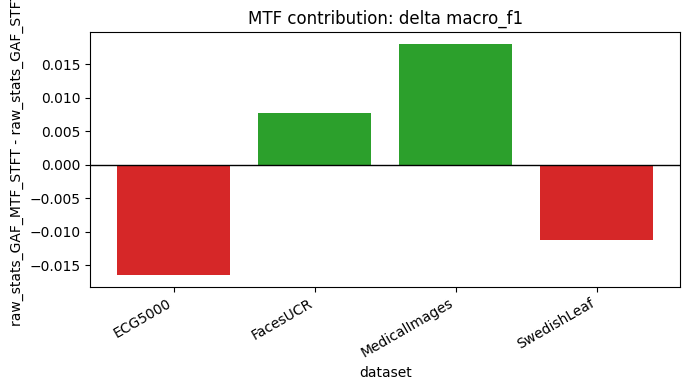

In [11]:
if MTF_COMPARISON_PATH.exists():
    mtf_comparison = pd.read_csv(MTF_COMPARISON_PATH)
    delta_cols = [col for col in mtf_comparison.columns if col.startswith("delta_")]

    print("Effect of adding MTF: raw_stats_GAF_STFT -> raw_stats_GAF_MTF_STFT")
    display(
        mtf_comparison[
            [
                "dataset_name",
                "dataset_size",
                "delta_loss",
                "delta_accuracy",
                "delta_balanced_accuracy",
                "delta_macro_f1",
                "delta_weighted_f1",
            ]
        ].style.format(
            {
                "delta_loss": "{:+.4f}",
                "delta_accuracy": "{:+.4f}",
                "delta_balanced_accuracy": "{:+.4f}",
                "delta_macro_f1": "{:+.4f}",
                "delta_weighted_f1": "{:+.4f}",
            }
        ).background_gradient(subset=["delta_macro_f1", "delta_weighted_f1", "delta_accuracy"], cmap="RdYlGn")
    )

    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(mtf_comparison)), 4))
    ax.bar(mtf_comparison["dataset_name"], mtf_comparison["delta_macro_f1"], color=np.where(mtf_comparison["delta_macro_f1"] >= 0, "tab:green", "tab:red"))
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("MTF contribution: delta macro_f1")
    ax.set_ylabel("raw_stats_GAF_MTF_STFT - raw_stats_GAF_STFT")
    ax.set_xlabel("dataset")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    mtf_comparison = pd.DataFrame()
    print(f"No MTF comparison found: {MTF_COMPARISON_PATH}")


Best method overall after adding representation concat experiments:


,dataset_name,dataset_size,experiment_group,method,macro_f1,weighted_f1,balanced_accuracy,accuracy,loss
4,ECG5000,5000,architecture,raw_GAF,0.6060,0.9337,0.5843,0.9371,0.3115
11,FacesUCR,2250,architecture,STFT,0.8640,0.8986,0.8507,0.9020,0.4890
21,MedicalImages,1141,architecture,raw,0.7604,0.7792,0.7613,0.7789,0.6426
30,SwedishLeaf,1125,architecture,raw,0.9424,0.9415,0.9433,0.9424,0.1684


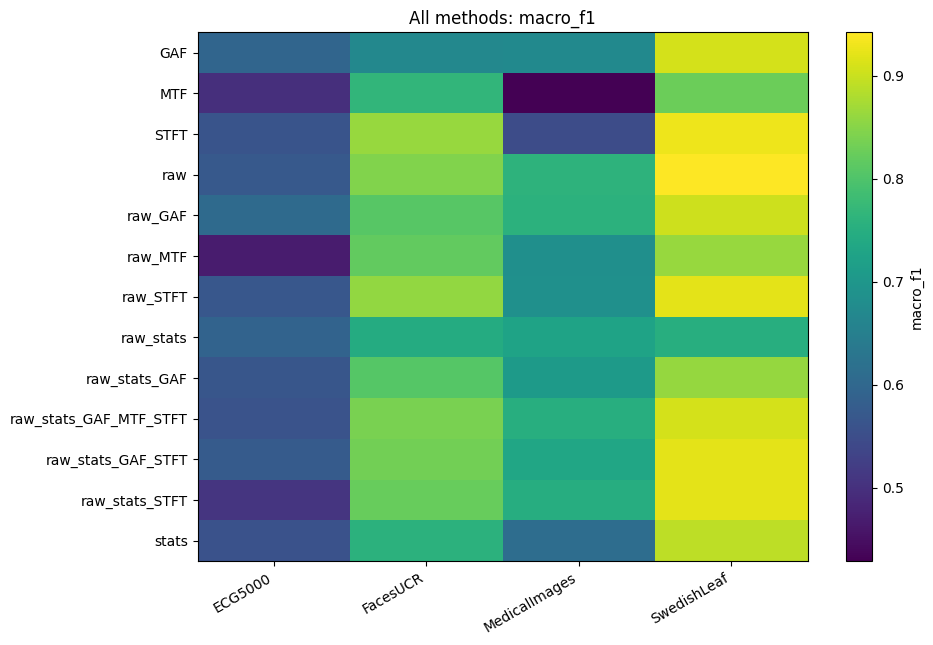

In [12]:
if not representation_summary.empty:
    combined_summary = pd.concat(
        [
            summary.assign(experiment_group="architecture"),
            representation_summary.assign(experiment_group="representation_concat"),
        ],
        ignore_index=True,
    )

    combined_best = (
        combined_summary
        .loc[combined_summary.groupby("dataset_name")["macro_f1"].idxmax()]
        .sort_values("dataset_name")
    )

    print("Best method overall after adding representation concat experiments:")
    display(
        combined_best[
            [
                "dataset_name",
                "dataset_size",
                "experiment_group",
                "method",
                "macro_f1",
                "weighted_f1",
                "balanced_accuracy",
                "accuracy",
                "loss",
            ]
        ].style.format(
            {
                "macro_f1": "{:.4f}",
                "weighted_f1": "{:.4f}",
                "balanced_accuracy": "{:.4f}",
                "accuracy": "{:.4f}",
                "loss": "{:.4f}",
            }
        )
    )

    combined_pivot = combined_summary.pivot_table(index="method", columns="dataset_name", values="macro_f1", aggfunc="max")
    fig, ax = plt.subplots(figsize=(1.2 * combined_pivot.shape[1] + 5, 0.35 * combined_pivot.shape[0] + 2))
    im = ax.imshow(combined_pivot, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(combined_pivot.shape[1]), labels=combined_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(combined_pivot.shape[0]), labels=combined_pivot.index)
    ax.set_title("All methods: macro_f1")
    fig.colorbar(im, ax=ax, label="macro_f1")
    plt.tight_layout()
    plt.show()


## Multimodal Fusion Experiments

Results for:

- gated fusion
- residual gated fusion with vector alpha
- residual gated fusion with scalar alpha
- FiLM fusion

Each fusion is evaluated on `raw_STFT`, `raw_GAF`, `raw_stats_STFT`, and `raw_stats_GAF_STFT`. The importance block uses learned gates, alpha, gamma, and beta coefficients saved during evaluation.

In [13]:
MULTIMODAL_RESULTS_DIR = PROJECT_ROOT / "results" / "multimodal_architecture_results"
MULTIMODAL_SUMMARY_PATH = MULTIMODAL_RESULTS_DIR / "summary.csv"
MULTIMODAL_IMPORTANCE_PATH = MULTIMODAL_RESULTS_DIR / "importance_summary.csv"

if MULTIMODAL_SUMMARY_PATH.exists():
    multimodal_summary = pd.read_csv(MULTIMODAL_SUMMARY_PATH)
    multimodal_summary["dataset_size"] = multimodal_summary["total_size"].astype(int)
    multimodal_summary[["fusion", "modality_combo"]] = multimodal_summary["method"].str.split("__", n=1, expand=True)
    multimodal_summary = multimodal_summary.sort_values(["dataset_name", "fusion", "modality_combo"]).reset_index(drop=True)
    print(f"Loaded {len(multimodal_summary)} rows from {MULTIMODAL_SUMMARY_PATH}")
    display(multimodal_summary.head())
else:
    multimodal_summary = pd.DataFrame()
    print(f"No multimodal summary found: {MULTIMODAL_SUMMARY_PATH}")

if MULTIMODAL_IMPORTANCE_PATH.exists():
    multimodal_importance = pd.read_csv(MULTIMODAL_IMPORTANCE_PATH)
    print(f"Loaded {len(multimodal_importance)} importance rows from {MULTIMODAL_IMPORTANCE_PATH}")
    display(multimodal_importance.head())
else:
    multimodal_importance = pd.DataFrame()
    print(f"No multimodal importance summary found: {MULTIMODAL_IMPORTANCE_PATH}")


Loaded 64 rows from /Users/roman/Desktop/НИР/FUTURE/results/multimodal_architecture_results/summary.csv


,method,dataset_name,train_size,test_size,total_size,channels,time_steps,num_classes,loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,dataset_size,fusion,modality_combo
0,film_fusion__raw_GAF,ECG5000,500,4500,5000,1,140,5,0.3391,0.9362,0.5694,0.6719,0.5694,0.6041,0.9271,0.9362,0.9305,5000,film_fusion,raw_GAF
1,film_fusion__raw_STFT,ECG5000,500,4500,5000,1,140,5,0.3053,0.9378,0.5827,0.6884,0.5827,0.6128,0.9309,0.9378,0.9334,5000,film_fusion,raw_STFT
2,film_fusion__raw_stats_GAF_STFT,ECG5000,500,4500,5000,1,140,5,0.3069,0.9391,0.5561,0.7834,0.5561,0.6082,0.9311,0.9391,0.9318,5000,film_fusion,raw_stats_GAF_STFT
3,film_fusion__raw_stats_STFT,ECG5000,500,4500,5000,1,140,5,0.3120,0.9309,0.5602,0.6865,0.5602,0.5815,0.9272,0.9309,0.9276,5000,film_fusion,raw_stats_STFT
4,gated_fusion__raw_GAF,ECG5000,500,4500,5000,1,140,5,0.3862,0.9347,0.5542,0.6549,0.5542,0.5903,0.9257,0.9347,0.9286,5000,gated_fusion,raw_GAF


Loaded 108 importance rows from /Users/roman/Desktop/НИР/FUTURE/results/multimodal_architecture_results/importance_summary.csv


,dataset_name,method,fusion,modality_combo,coefficient,target,value,std
0,ECG5000,gated_fusion__raw_STFT,gated_fusion,raw_STFT,gate,raw,0.3214,0.1314
1,ECG5000,gated_fusion__raw_STFT,gated_fusion,raw_STFT,gate,stft,0.6786,0.1314
2,ECG5000,gated_fusion__raw_GAF,gated_fusion,raw_GAF,gate,raw,0.3960,0.1077
3,ECG5000,gated_fusion__raw_GAF,gated_fusion,raw_GAF,gate,gaf,0.6040,0.1077
4,ECG5000,gated_fusion__raw_stats_STFT,gated_fusion,raw_stats_STFT,gate,raw,0.1593,0.1069


Best multimodal method by macro_f1:


,dataset_name,dataset_size,fusion,modality_combo,macro_f1,weighted_f1,balanced_accuracy,accuracy,loss
1,ECG5000,5000,film_fusion,raw_STFT,0.6128,0.9334,0.5827,0.9378,0.3053
21,FacesUCR,2250,gated_fusion,raw_STFT,0.9110,0.9329,0.9026,0.9337,0.2653
44,MedicalImages,1141,residual_gated_fusion_vector_alpha,raw_GAF,0.7690,0.7812,0.7954,0.7776,0.6398
63,SwedishLeaf,1125,residual_gated_fusion_vector_alpha,raw_stats_STFT,0.9508,0.9498,0.9526,0.9504,0.1347


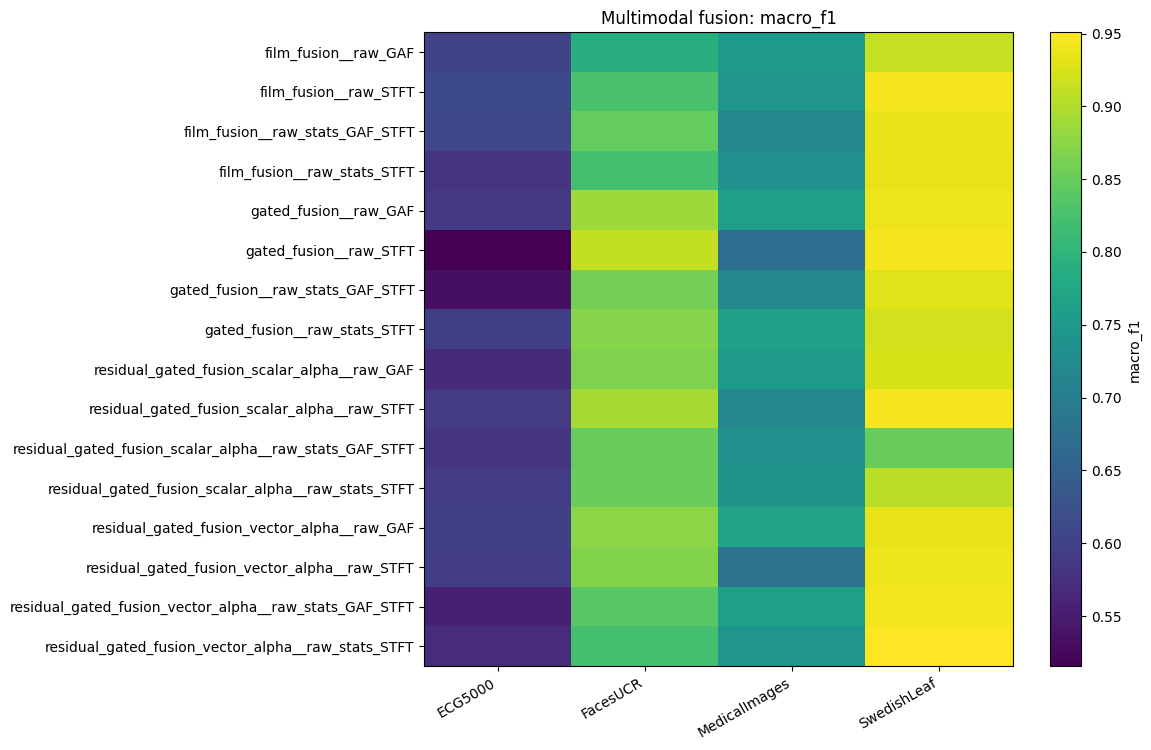

In [14]:
if not multimodal_summary.empty:
    multimodal_best = (
        multimodal_summary
        .loc[multimodal_summary.groupby("dataset_name")["macro_f1"].idxmax()]
        .sort_values("dataset_name")
    )

    print("Best multimodal method by macro_f1:")
    display(
        multimodal_best[
            [
                "dataset_name",
                "dataset_size",
                "fusion",
                "modality_combo",
                "macro_f1",
                "weighted_f1",
                "balanced_accuracy",
                "accuracy",
                "loss",
            ]
        ].style.format(
            {
                "macro_f1": "{:.4f}",
                "weighted_f1": "{:.4f}",
                "balanced_accuracy": "{:.4f}",
                "accuracy": "{:.4f}",
                "loss": "{:.4f}",
            }
        )
    )

    multimodal_pivot = multimodal_summary.pivot_table(
        index="method",
        columns="dataset_name",
        values="macro_f1",
        aggfunc="max",
    )
    fig, ax = plt.subplots(figsize=(1.2 * multimodal_pivot.shape[1] + 7, 0.35 * multimodal_pivot.shape[0] + 2))
    im = ax.imshow(multimodal_pivot, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(multimodal_pivot.shape[1]), labels=multimodal_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(multimodal_pivot.shape[0]), labels=multimodal_pivot.index)
    ax.set_title("Multimodal fusion: macro_f1")
    fig.colorbar(im, ax=ax, label="macro_f1")
    plt.tight_layout()
    plt.show()
else:
    print("Run experiments/multimodal_architecture_evaluating.py first to build this section.")


In [15]:
if not multimodal_summary.empty:
    multimodal_ranked = add_metric_ranks(multimodal_summary, metric_cols)
    multimodal_fusion_rating = (
        multimodal_ranked
        .groupby("fusion", as_index=False)
        .agg(
            mean_rank=("mean_rank", "mean"),
            wins_macro_f1=("is_best_macro_f1", "sum"),
            mean_macro_f1=("macro_f1", "mean"),
            mean_weighted_f1=("weighted_f1", "mean"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            mean_accuracy=("accuracy", "mean"),
            mean_loss=("loss", "mean"),
        )
        .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print("Multimodal fusion rating: lower mean_rank is better")
    display(
        multimodal_fusion_rating.style.format(
            {
                "mean_rank": "{:.2f}",
                "mean_macro_f1": "{:.4f}",
                "mean_weighted_f1": "{:.4f}",
                "mean_balanced_accuracy": "{:.4f}",
                "mean_accuracy": "{:.4f}",
                "mean_loss": "{:.4f}",
            }
        ).background_gradient(subset=["mean_rank"], cmap="viridis_r")
    )

    combo_rating = (
        multimodal_ranked
        .groupby("modality_combo", as_index=False)
        .agg(
            mean_rank=("mean_rank", "mean"),
            mean_macro_f1=("macro_f1", "mean"),
            mean_weighted_f1=("weighted_f1", "mean"),
            mean_accuracy=("accuracy", "mean"),
        )
        .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
    )
    print("Modality combination rating")
    display(combo_rating.style.format({"mean_rank": "{:.2f}", "mean_macro_f1": "{:.4f}", "mean_weighted_f1": "{:.4f}", "mean_accuracy": "{:.4f}"}))


Multimodal fusion rating: lower mean_rank is better


,fusion,mean_rank,wins_macro_f1,mean_macro_f1,mean_weighted_f1,mean_balanced_accuracy,mean_accuracy,mean_loss
0,residual_gated_fusion_vector_alpha,7.69,2,0.7781,0.8790,0.7717,0.8812,0.4628
1,gated_fusion,8.54,1,0.7761,0.8793,0.7754,0.8809,0.5015
2,film_fusion,8.74,1,0.7731,0.8714,0.7657,0.8746,0.4847
3,residual_gated_fusion_scalar_alpha,8.88,0,0.7731,0.8722,0.7654,0.8742,0.4790


Modality combination rating


,modality_combo,mean_rank,mean_macro_f1,mean_weighted_f1,mean_accuracy
1,raw_STFT,6.97,0.7752,0.8805,0.8822
0,raw_GAF,8.06,0.7829,0.8790,0.8812
3,raw_stats_STFT,9.11,0.7754,0.8728,0.8745
2,raw_stats_GAF_STFT,9.72,0.7669,0.8696,0.8730


In [16]:
if not multimodal_summary.empty:
    residual_alpha_comparison = multimodal_summary[
        multimodal_summary["fusion"].isin(
            [
                "residual_gated_fusion_vector_alpha",
                "residual_gated_fusion_scalar_alpha",
            ]
        )
    ].copy()

    residual_alpha_pivot = residual_alpha_comparison.pivot_table(
        index=["dataset_name", "modality_combo"],
        columns="fusion",
        values="macro_f1",
        aggfunc="max",
    ).reset_index()

    if {
        "residual_gated_fusion_vector_alpha",
        "residual_gated_fusion_scalar_alpha",
    }.issubset(residual_alpha_pivot.columns):
        residual_alpha_pivot["delta_vector_minus_scalar"] = (
            residual_alpha_pivot["residual_gated_fusion_vector_alpha"]
            - residual_alpha_pivot["residual_gated_fusion_scalar_alpha"]
        )

    print("Residual gated fusion: vector alpha vs scalar alpha by macro_f1")
    display(
        residual_alpha_pivot.style.format(
            {
                "residual_gated_fusion_vector_alpha": "{:.4f}",
                "residual_gated_fusion_scalar_alpha": "{:.4f}",
                "delta_vector_minus_scalar": "{:+.4f}",
            }
        ).background_gradient(subset=["delta_vector_minus_scalar"], cmap="RdYlGn")
    )


Residual gated fusion: vector alpha vs scalar alpha by macro_f1


fusion,dataset_name,modality_combo,residual_gated_fusion_scalar_alpha,residual_gated_fusion_vector_alpha,delta_vector_minus_scalar
0,ECG5000,raw_GAF,0.5694,0.5987,+0.0293
1,ECG5000,raw_STFT,0.5918,0.5951,+0.0033
2,ECG5000,raw_stats_GAF_STFT,0.5835,0.5547,-0.0288
3,ECG5000,raw_stats_STFT,0.5909,0.5713,-0.0196
4,FacesUCR,raw_GAF,0.8661,0.8757,+0.0096
5,FacesUCR,raw_STFT,0.8921,0.8684,-0.0237
6,FacesUCR,raw_stats_GAF_STFT,0.8502,0.8387,-0.0115
7,FacesUCR,raw_stats_STFT,0.8520,0.8228,-0.0292
8,MedicalImages,raw_GAF,0.7534,0.7690,+0.0156
9,MedicalImages,raw_STFT,0.7188,0.6818,-0.0371


Learned coefficient summary


,dataset_name,method,fusion,modality_combo,coefficient,target,value,std
0,ECG5000,gated_fusion__raw_STFT,gated_fusion,raw_STFT,gate,raw,0.3214,0.1314
1,ECG5000,gated_fusion__raw_STFT,gated_fusion,raw_STFT,gate,stft,0.6786,0.1314
2,ECG5000,gated_fusion__raw_GAF,gated_fusion,raw_GAF,gate,raw,0.3960,0.1077
3,ECG5000,gated_fusion__raw_GAF,gated_fusion,raw_GAF,gate,gaf,0.6040,0.1077
4,ECG5000,gated_fusion__raw_stats_STFT,gated_fusion,raw_stats_STFT,gate,raw,0.1593,0.1069
5,ECG5000,gated_fusion__raw_stats_STFT,gated_fusion,raw_stats_STFT,gate,stats,0.5855,0.2137
6,ECG5000,gated_fusion__raw_stats_STFT,gated_fusion,raw_stats_STFT,gate,stft,0.2552,0.1090
7,ECG5000,gated_fusion__raw_stats_GAF_STFT,gated_fusion,raw_stats_GAF_STFT,gate,raw,0.2582,0.1800
8,ECG5000,gated_fusion__raw_stats_GAF_STFT,gated_fusion,raw_stats_GAF_STFT,gate,stats,0.1896,0.0174
9,ECG5000,gated_fusion__raw_stats_GAF_STFT,gated_fusion,raw_stats_GAF_STFT,gate,gaf,0.1853,0.0319


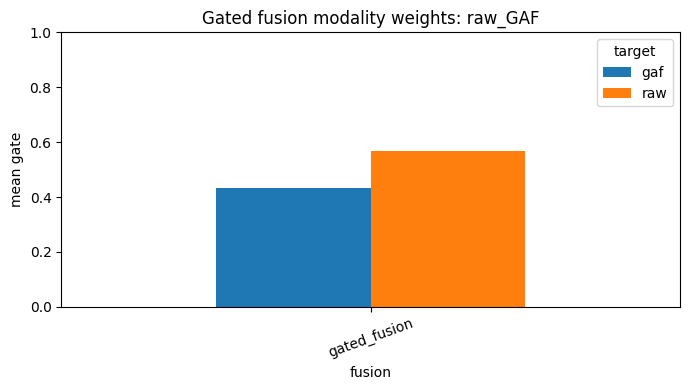

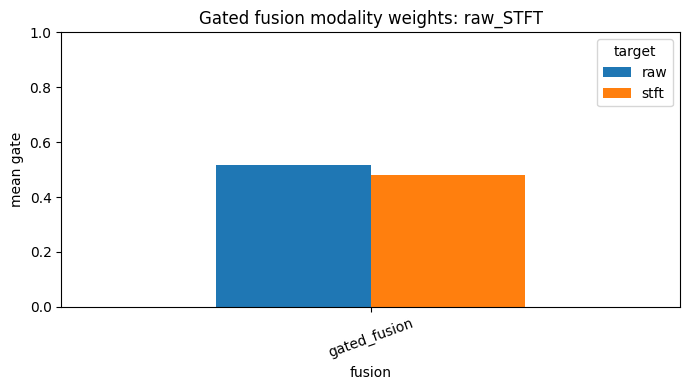

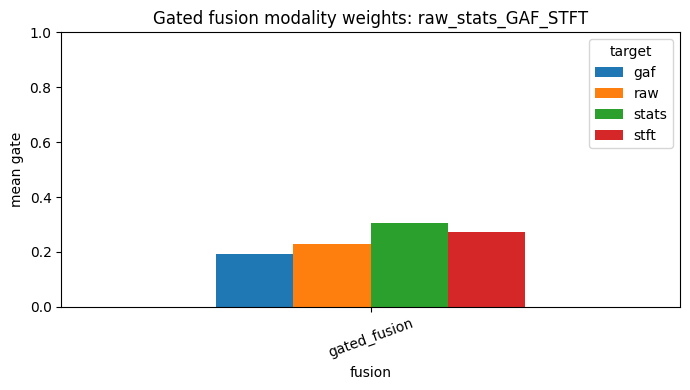

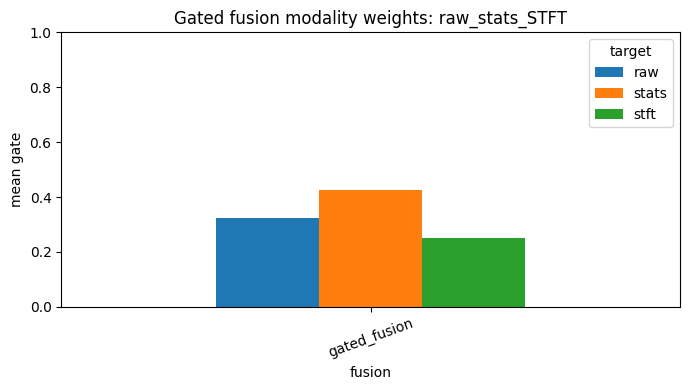

,fusion,modality_combo,coefficient,target,value
0,film_fusion,raw_GAF,beta_abs_mean,raw_shift,0.2522
1,film_fusion,raw_GAF,gamma_abs_mean,raw_modulation,0.4439
2,film_fusion,raw_STFT,beta_abs_mean,raw_shift,0.2917
3,film_fusion,raw_STFT,gamma_abs_mean,raw_modulation,0.4487
4,film_fusion,raw_stats_GAF_STFT,beta_abs_mean,raw_shift,0.3763
5,film_fusion,raw_stats_GAF_STFT,gamma_abs_mean,raw_modulation,0.4252
6,film_fusion,raw_stats_STFT,beta_abs_mean,raw_shift,0.3719
7,film_fusion,raw_stats_STFT,gamma_abs_mean,raw_modulation,0.4168
8,residual_gated_fusion_scalar_alpha,raw_GAF,alpha_abs_mean,residual_delta,0.3935
9,residual_gated_fusion_scalar_alpha,raw_STFT,alpha_abs_mean,residual_delta,0.3625


In [17]:
if not multimodal_importance.empty:
    print("Learned coefficient summary")
    display(
        multimodal_importance.style.format(
            {
                "value": "{:.4f}",
                "std": "{:.4f}",
            }
        )
    )

    gated_importance = multimodal_importance[multimodal_importance["coefficient"].eq("gate")]
    if not gated_importance.empty:
        gated_mean = (
            gated_importance
            .groupby(["fusion", "modality_combo", "target"], as_index=False)["value"]
            .mean()
        )
        for combo, combo_df in gated_mean.groupby("modality_combo", sort=True):
            pivot = combo_df.pivot(index="fusion", columns="target", values="value")
            ax = pivot.plot(kind="bar", figsize=(max(7, 1.6 * pivot.shape[1]), 4), rot=20)
            ax.set_title(f"Gated fusion modality weights: {combo}")
            ax.set_ylabel("mean gate")
            ax.set_ylim(0, 1)
            plt.tight_layout()
            plt.show()

    non_gate_importance = multimodal_importance[~multimodal_importance["coefficient"].eq("gate")]
    if not non_gate_importance.empty:
        importance_mean = (
            non_gate_importance
            .groupby(["fusion", "modality_combo", "coefficient", "target"], as_index=False)["value"]
            .mean()
        )
        display(
            importance_mean.style.format({"value": "{:.4f}"})
        )
else:
    print("No importance rows to display yet.")


По текущим экспериментам видно, что concat fusion пока не дает универсального выигрыша на всех датасетах. Лучшие результаты часто достигаются отдельными модальностями: stats стабильно сильны на ECG5000, MedicalImages и особенно SwedishLeaf, а raw лучше проявляется по balanced/macro-метрикам на части датасетов. Единственный явно сильный пример полезного fusion — FacesUCR, где связка raw + STFT стала лучшей почти по всем метрикам.

- statistical features — сейчас самая стабильная модальность;
- STFT — самая перспективная image-модальность;
- GAF может быть полезен для macro F1 / сложных классов;
- MTF пока не показал явной пользы;
- concat fusion работает, но только когда модальности действительно дополняют друг друга.

# 3x Concat